## Predicting Revenue from Online Shopper Session Features

### Load dataset
#### Souce - [online_shoppers+pucrhase_intention_dataset](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset)

In [1]:
# Load the Online Shoppers dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

file_path = r"online+shoppers+purchasing+intention+dataset\online_shoppers_intention.csv"
df = pd.read_csv(file_path)

# Plotting configuration
sns.set_style("whitegrid")

# Show the dataset
print("Dataset shape:", df.shape)      # expected: (12330, 18)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

Dataset shape: (12330, 18)

Column names:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

First 10 rows:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


### For Correlation

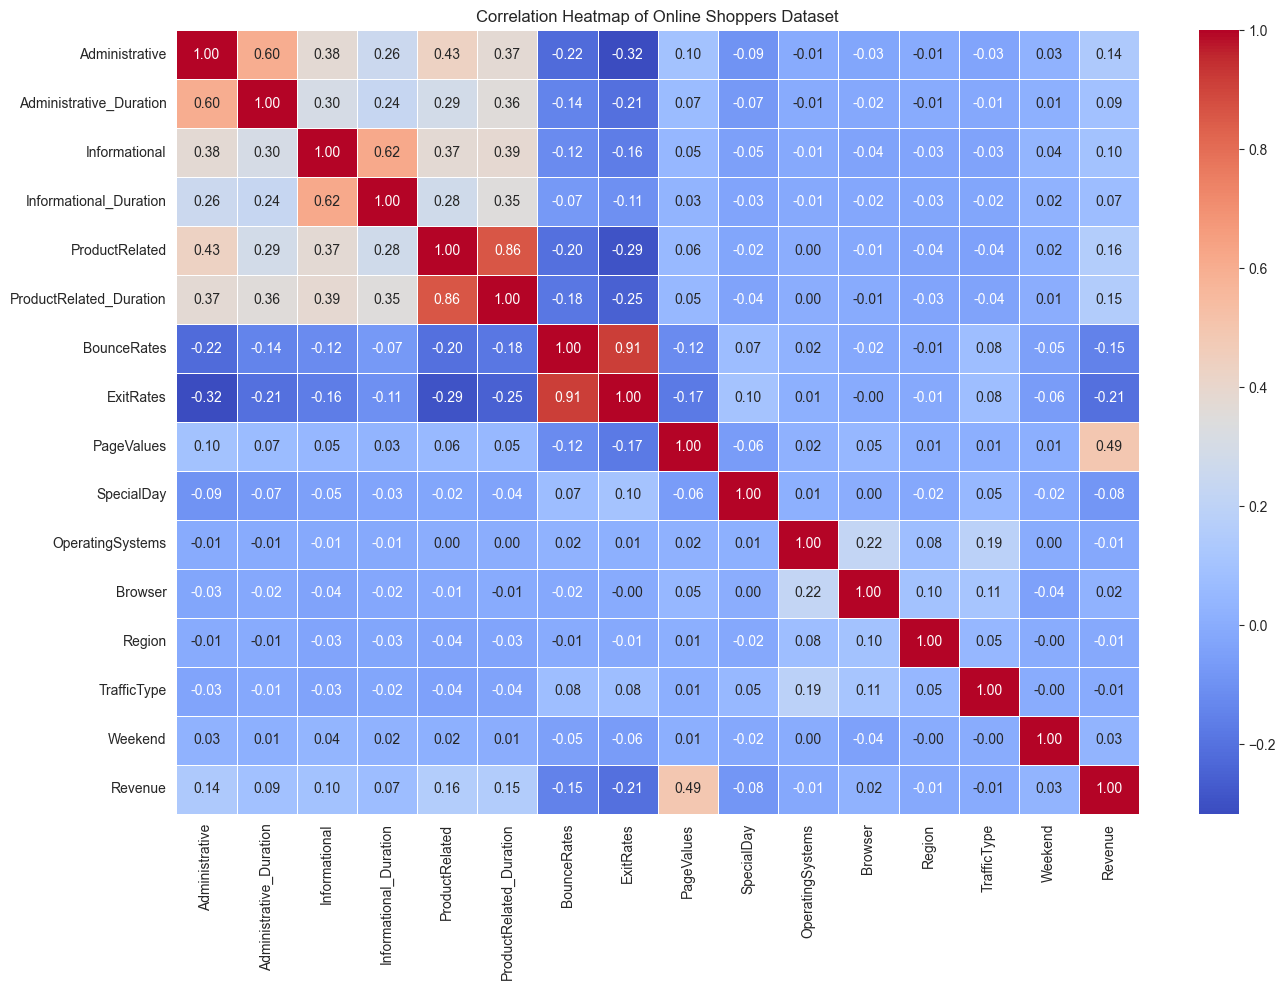

In [2]:
# Convert boolean columns to 0/1
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

# Use only numeric columns for correlation
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Correlation matrix
corr = numeric_df.corr()

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Online Shoppers Dataset")
plt.tight_layout()
plt.show()


## Countplot for Revenue

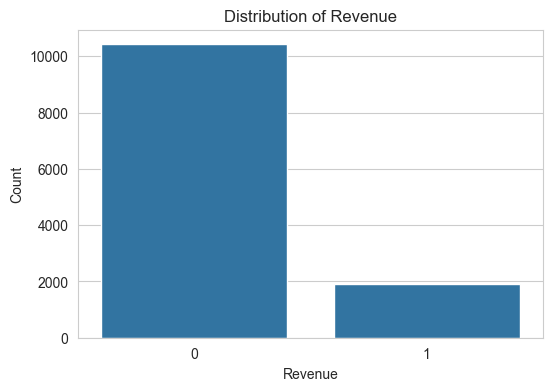

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Revenue", data=df)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()


## Countplot for Month

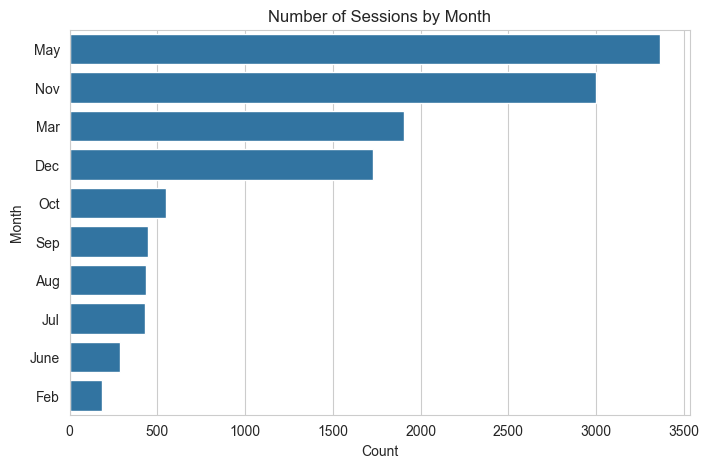

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(y="Month", data=df, order=df["Month"].value_counts().index)
plt.title("Number of Sessions by Month")
plt.xlabel("Count")
plt.ylabel("Month")
plt.show()


## Boxplot for PageValues by Revenue

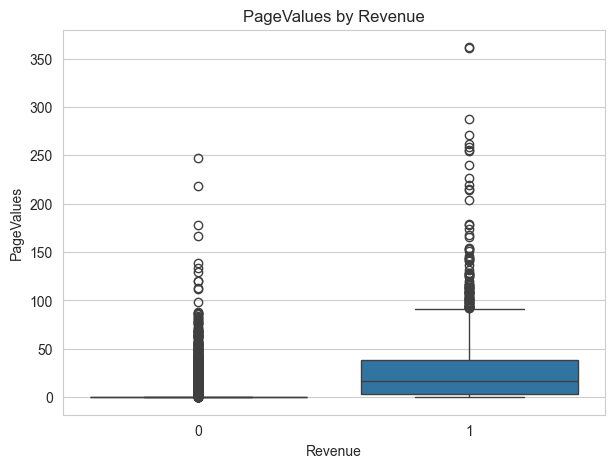

In [5]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="Revenue", y="PageValues", data=df)
plt.title("PageValues by Revenue")
plt.xlabel("Revenue")
plt.ylabel("PageValues")
plt.show()


 ## Scatterplot for ExitRates and PageValues

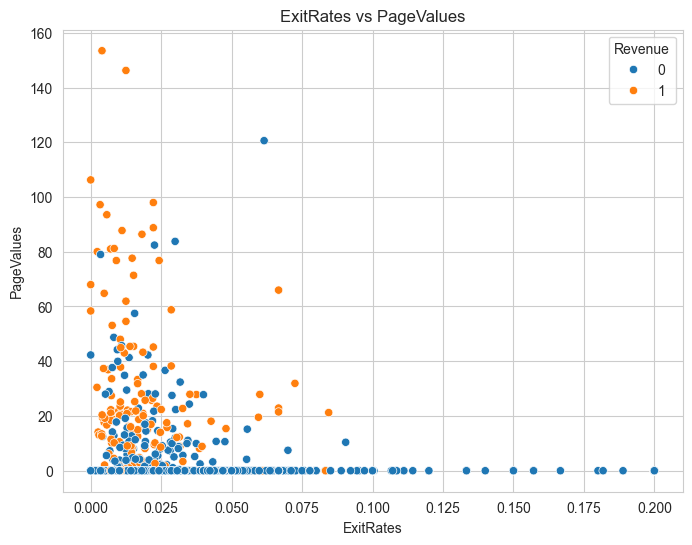

In [6]:
# Use a sample so the plot is not too crowded
sample_df = df.sample(1000, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample_df, x="ExitRates", y="PageValues", hue="Revenue")
plt.title("ExitRates vs PageValues")
plt.xlabel("ExitRates")
plt.ylabel("PageValues")
plt.show()


##  Histogram for ProductRelated_Duration

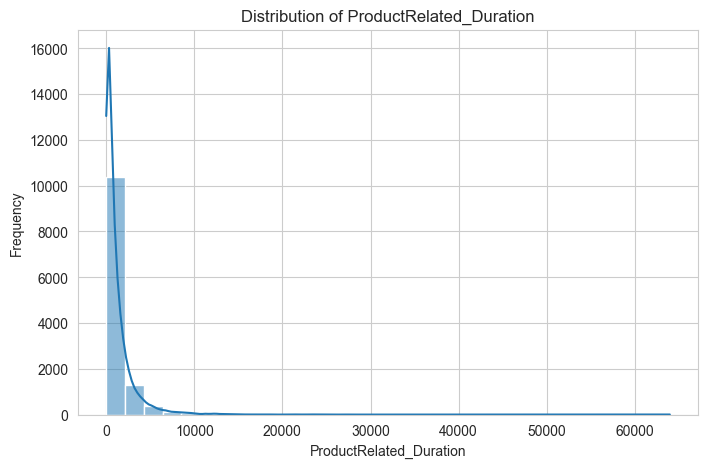

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df["ProductRelated_Duration"], bins=30, kde=True)
plt.title("Distribution of ProductRelated_Duration")
plt.xlabel("ProductRelated_Duration")
plt.ylabel("Frequency")
plt.show()


## Numeric features vs Revenue

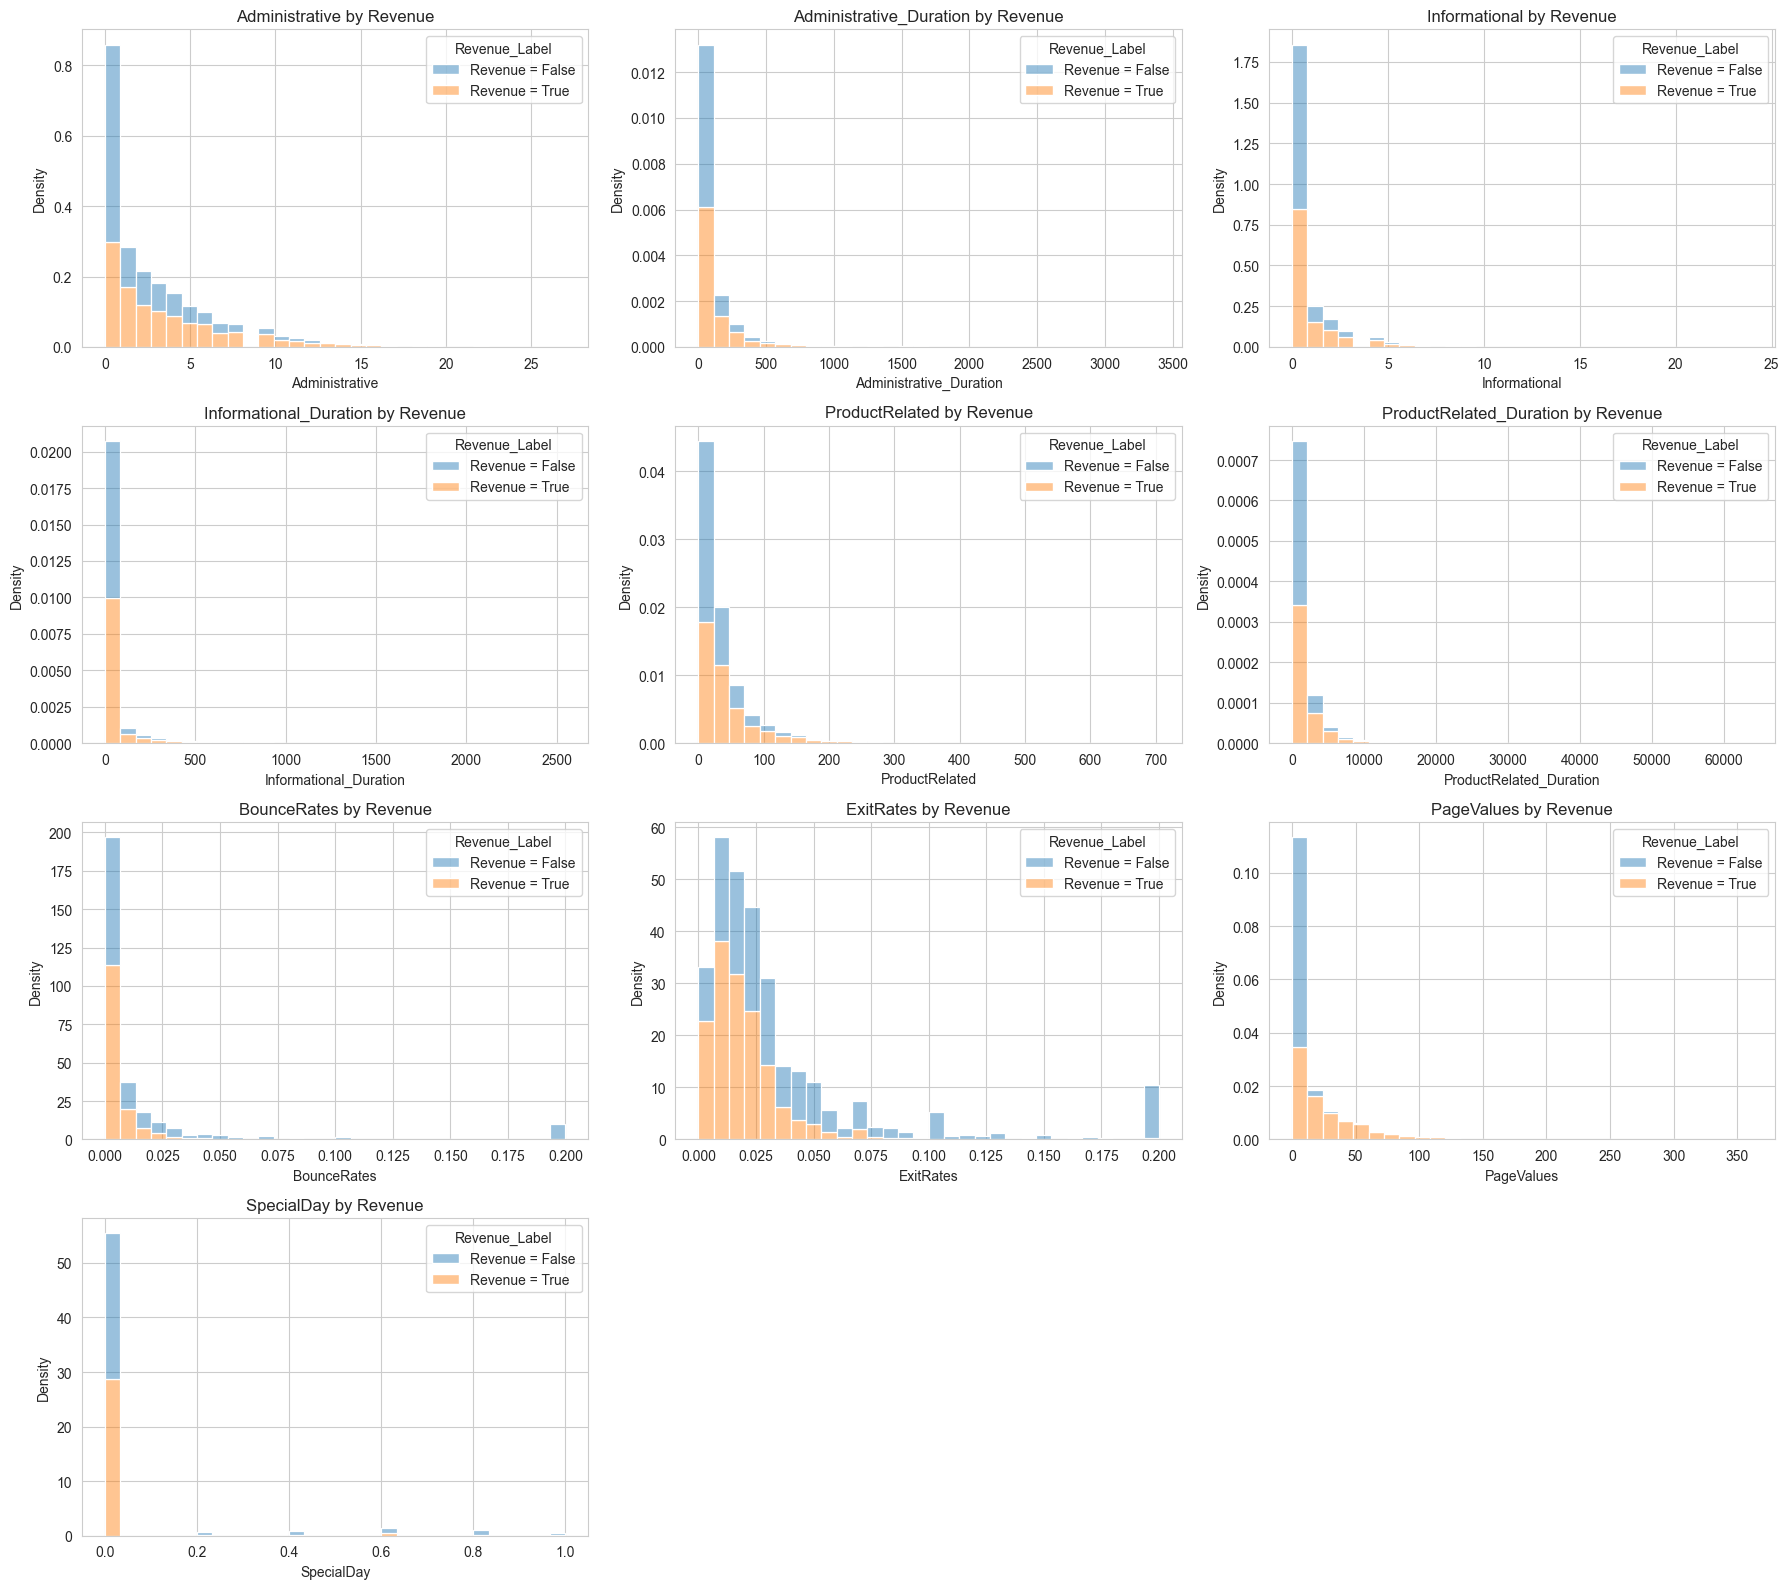

In [8]:
# Better labels for the legend
df["Revenue_Label"] = df["Revenue"].map({
    0: "Revenue = False",
    1: "Revenue = True"
})


numeric_features = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

n_cols = 3
n_rows = math.ceil(len(numeric_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_features):
    sns.histplot(
        data=df,
        x=col,
        hue="Revenue_Label",
        hue_order=["Revenue = False", "Revenue = True"],
        multiple="stack",
        bins=30,
        stat="density",
        common_norm=False,
        alpha=0.45,
        ax=ax
    )
    ax.set_title(f"{col} by Revenue")

for ax in axes[len(numeric_features):]:
    ax.remove()

plt.tight_layout()
plt.show()


#### No Missing Value,

## Categories features vs Revenue

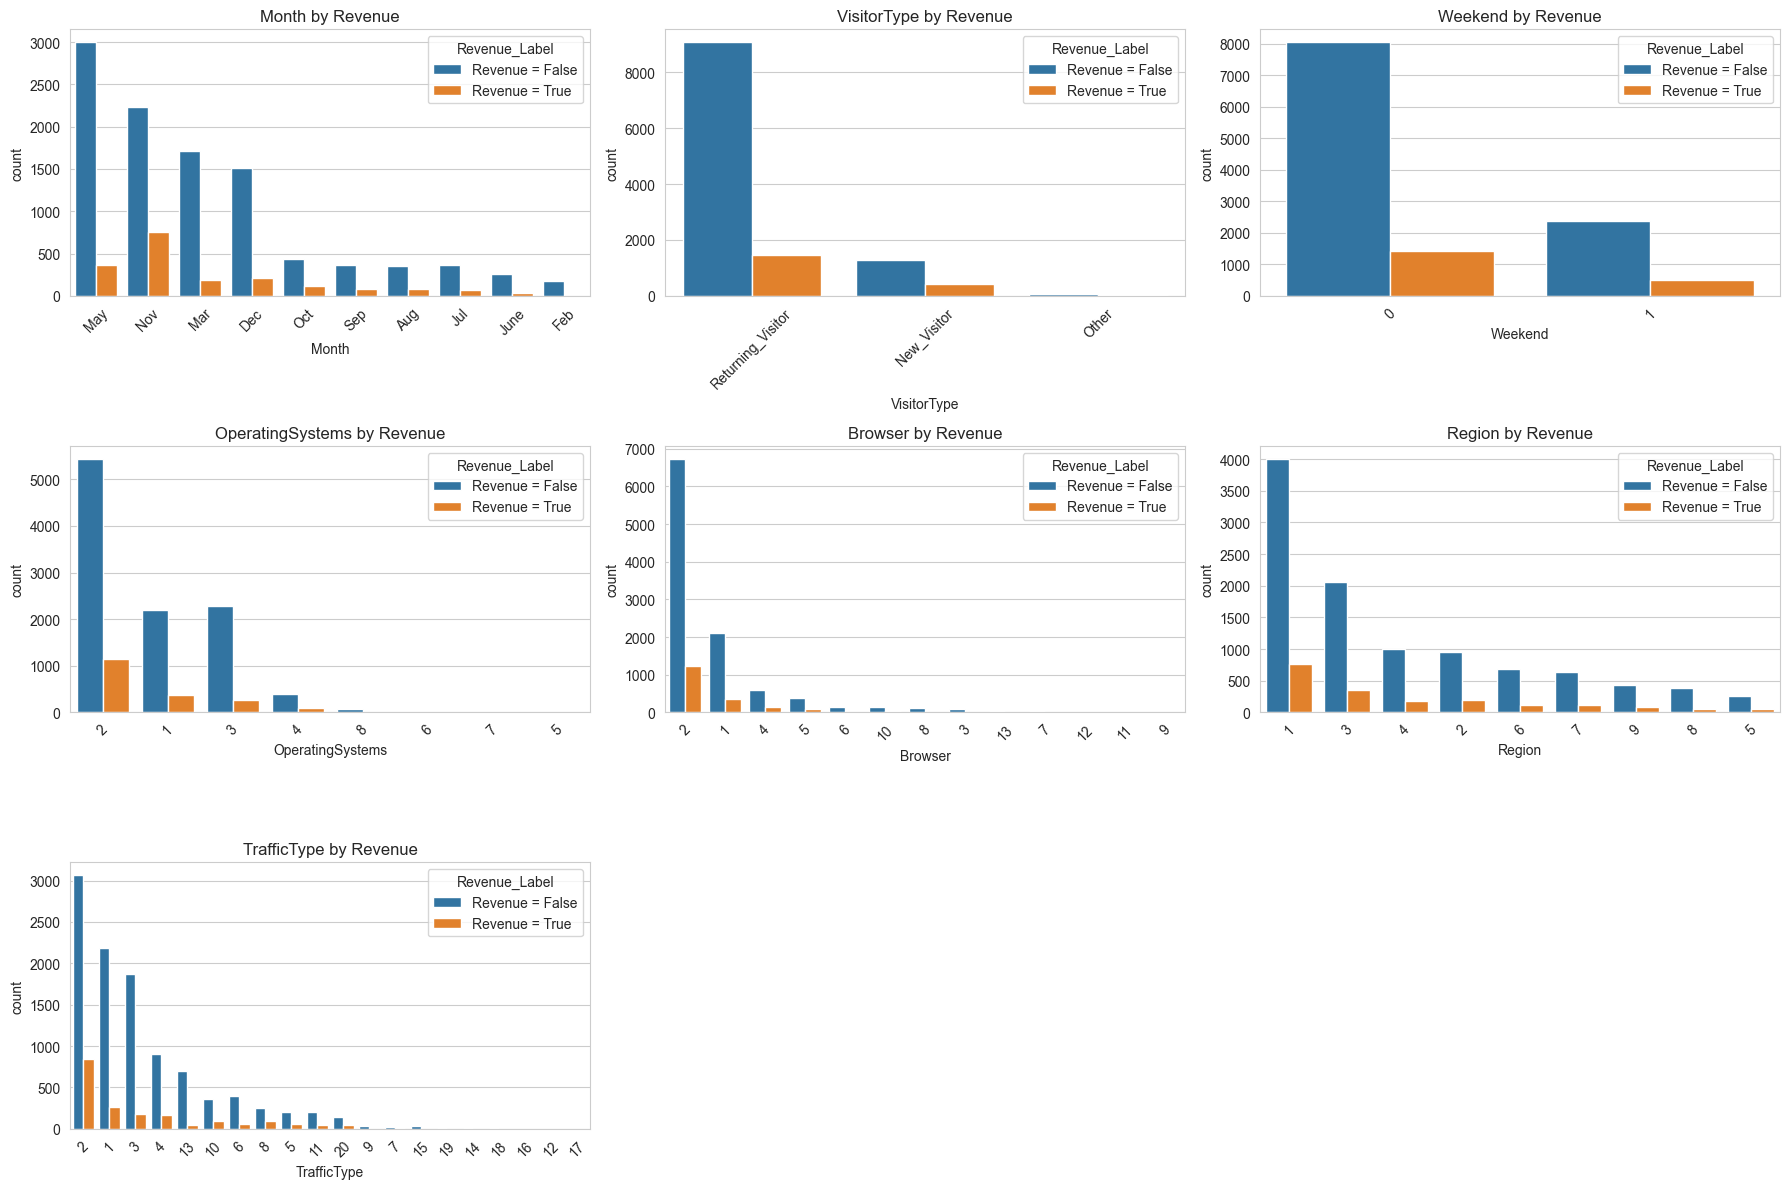

In [9]:
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

n_cols = 3
n_rows = math.ceil(len(categorical_features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="Revenue_Label", order=order, ax=ax)
    ax.set_title(f"{col} by Revenue")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(categorical_features):]:
    ax.remove()

plt.tight_layout()
plt.show()


### Train-Test Split (Stratified)

In [10]:
from sklearn.model_selection import train_test_split

target_col = "Revenue"

feature_cols = [col for col in df.columns if col not in [target_col, "Revenue_Label"]]

numeric_features_model = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

categorical_features_model = [
    "Month",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "VisitorType",
    "Weekend"
]

X = df[feature_cols].copy()
y = df[target_col].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\ny_train distribution:")
print(y_train.value_counts())
print("\ny_test distribution:")
print(y_test.value_counts())


X_train shape: (9864, 17)
X_test shape: (2466, 17)

y_train distribution:
Revenue
0    8338
1    1526
Name: count, dtype: int64

y_test distribution:
Revenue
0    2084
1     382
Name: count, dtype: int64


## Feature Scaling

#### One Hot Encode

In [11]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features_model),
        ("cat", encoder, categorical_features_model)
    ]
)

X_train_tree = preprocessor_tree.fit_transform(X_train)
X_test_tree = preprocessor_tree.transform(X_test)

encoded_cat_names = preprocessor_tree.named_transformers_["cat"].get_feature_names_out(
    categorical_features_model
).tolist()

tree_feature_names = numeric_features_model + encoded_cat_names

X_train_tree = pd.DataFrame(X_train_tree, columns=tree_feature_names, index=X_train.index)
X_test_tree = pd.DataFrame(X_test_tree, columns=tree_feature_names, index=X_test.index)

print("Tree-model training shape:", X_train_tree.shape)
print("Tree-model test shape:", X_test_tree.shape)

display(X_train_tree.head())


Tree-model training shape: (9864, 75)
Tree-model test shape: (2466, 75)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_0,Weekend_1
4263,8.0,732.25,0.0,0.0,34.0,1345.755952,0.005128,0.013342,12.274195,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5905,0.0,0.00,0.0,0.0,4.0,157.200000,0.040000,0.100000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
9434,0.0,0.00,0.0,0.0,4.0,42.000000,0.000000,0.050000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3505,2.0,338.00,0.0,0.0,17.0,1205.566667,0.012500,0.037500,19.236250,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2067,0.0,0.00,0.0,0.0,32.0,827.646212,0.000000,0.000587,54.676348,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


#### Scaling for Logistic Regression + One Hot Encode

In [12]:
try:
    encoder_lr = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder_lr = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_model),
        ("cat", encoder_lr, categorical_features_model)
    ]
)

X_train_lr = preprocessor_lr.fit_transform(X_train)
X_test_lr = preprocessor_lr.transform(X_test)

encoded_cat_names_lr = preprocessor_lr.named_transformers_["cat"].get_feature_names_out(
    categorical_features_model
).tolist()

lr_feature_names = numeric_features_model + encoded_cat_names_lr

X_train_lr = pd.DataFrame(X_train_lr, columns=lr_feature_names, index=X_train.index)
X_test_lr = pd.DataFrame(X_test_lr, columns=lr_feature_names, index=X_test.index)

print("Logistic Regression training shape:", X_train_lr.shape)
print("Logistic Regression test shape:", X_test_lr.shape)

display(X_train_lr.head())


Logistic Regression training shape: (9864, 75)
Logistic Regression test shape: (2466, 75)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor,Weekend_0,Weekend_1
4263,1.712088,3.624745,-0.395782,-0.244589,0.058405,0.083393,-0.353793,-0.612923,0.341014,3.663440,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
5905,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.539163,0.360698,1.159262,-0.320268,-0.311499,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
9434,-0.698294,-0.452341,-0.395782,-0.244589,-0.629459,-0.599504,-0.458865,0.136746,-0.320268,-0.311499,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3505,-0.095698,1.429605,-0.395782,-0.244589,-0.331385,0.009963,-0.202751,-0.118883,0.716100,3.663440,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2067,-0.698294,-0.452341,-0.395782,-0.244589,0.012548,-0.187989,-0.458865,-0.873776,2.625461,-0.311499,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


## Milestone 3: The Training Loop

### Use the 80/20 train-test split directly

For this version of **Milestone 3**, we train on the existing `X_train` split and evaluate directly on `X_test`.

In [13]:
# Imports needed for model training and test metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Reuse the existing 80/20 split directly for Milestone 3.
X_train_m3 = X_train
X_test_m3 = X_test
y_train_m3 = y_train
y_test_m3 = y_test

print("Milestone 3 training shape:", X_train_m3.shape)
print("Test shape:", X_test_m3.shape)

print("\nTraining class distribution:")
print(y_train_m3.value_counts())

print("\nTest class distribution:")
print(y_test_m3.value_counts())


Milestone 3 training shape: (9864, 17)
Test shape: (2466, 17)

Training class distribution:
Revenue
0    8338
1    1526
Name: count, dtype: int64

Test class distribution:
Revenue
0    2084
1     382
Name: count, dtype: int64


### Reuse preprocessing from the 80/20 split

This step avoids **data leakage (Data Leakage)**.  
The encoders and scaler were fit only on `X_train`, then applied to `X_test`.

In [14]:
# Reuse the preprocessing already fit on the training split.
X_train_tree_m3 = X_train_tree
X_test_tree_m3 = X_test_tree
X_train_lr_m3 = X_train_lr
X_test_lr_m3 = X_test_lr

print("Random Forest training matrix:", X_train_tree_m3.shape)
print("Random Forest test matrix:", X_test_tree_m3.shape)
print("Logistic Regression training matrix:", X_train_lr_m3.shape)
print("Logistic Regression test matrix:", X_test_lr_m3.shape)


Random Forest training matrix: (9864, 75)
Random Forest test matrix: (2466, 75)
Logistic Regression training matrix: (9864, 75)
Logistic Regression test matrix: (2466, 75)


### Train the baseline and main model

For classical machine learning, there is no manual epoch loop.  
The `fit()` function is the training loop handled internally by `scikit-learn`.

In [15]:
# Baseline model: Logistic Regression
lr_model = LogisticRegression(max_iter=2000, random_state=42)

# Main model: Random Forest
# n_jobs=1 avoids Windows sandbox permission issues during notebook execution.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1
)

# Train both models on the Milestone 3 training split
lr_model.fit(X_train_lr_m3, y_train_m3)
rf_model.fit(X_train_tree_m3, y_train_m3)

print("Both models trained successfully.")


Both models trained successfully.


### Compare training and test metrics

In [16]:
# Generate predictions for both training and test sets
lr_train_pred = lr_model.predict(X_train_lr_m3)
lr_test_pred = lr_model.predict(X_test_lr_m3)
lr_test_prob = lr_model.predict_proba(X_test_lr_m3)[:, 1]

rf_train_pred = rf_model.predict(X_train_tree_m3)
rf_test_pred = rf_model.predict(X_test_tree_m3)
rf_test_prob = rf_model.predict_proba(X_test_tree_m3)[:, 1]

# Store metrics in a table so they are easy to show on slides
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Train Accuracy": accuracy_score(y_train_m3, lr_train_pred),
        "Test Accuracy": accuracy_score(y_test_m3, lr_test_pred),
        "Test Precision": precision_score(y_test_m3, lr_test_pred),
        "Test Recall": recall_score(y_test_m3, lr_test_pred),
        "Test F1": f1_score(y_test_m3, lr_test_pred),
        "Test ROC-AUC": roc_auc_score(y_test_m3, lr_test_prob)
    },
    {
        "Model": "Random Forest",
        "Train Accuracy": accuracy_score(y_train_m3, rf_train_pred),
        "Test Accuracy": accuracy_score(y_test_m3, rf_test_pred),
        "Test Precision": precision_score(y_test_m3, rf_test_pred),
        "Test Recall": recall_score(y_test_m3, rf_test_pred),
        "Test F1": f1_score(y_test_m3, rf_test_pred),
        "Test ROC-AUC": roc_auc_score(y_test_m3, rf_test_prob)
    }
])

display(results_df.round(4))


,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.8862,0.8808,0.7366,0.3586,0.4824,0.8828
1,Random Forest,1.0000,0.8970,0.7712,0.4764,0.5890,0.9132


### Test confusion matrices

In [17]:
# Confusion matrices provide a clearer view than accuracy alone,
# especially because the dataset is imbalanced.
lr_cm = confusion_matrix(y_test_m3, lr_test_pred)
rf_cm = confusion_matrix(y_test_m3, rf_test_pred)

print("Logistic Regression confusion matrix:")
print(lr_cm)

print("\nRandom Forest confusion matrix:")
print(rf_cm)


Logistic Regression confusion matrix:
[[2035   49]
 [ 245  137]]

Random Forest confusion matrix:
[[2030   54]
 [ 200  182]]
